Reason of overfitting is complaxcity of model.



Regularization in Deep Learning


Regularization techniques are used to prevent overfitting and help a neural network generalize better on unseen data.

# What Is Regularization?

Regularization adds a penalty to the loss function so the model avoids learning overly complex patterns.

# 🔥 Why Overfitting Happens

Too many parameters

Small dataset

Very deep networks

Training too long

👉 Regularization controls model complexity

# 🔹 L2 Regularization 
📌 Definition

L2 regularization penalizes large weights by adding the sum of squared weights to the loss.

🧠 Intuition

Large weights = complex model

L2 forces weights to be small & smooth

📐 Loss Function


Loss = Original Loss + λ Σ(w²)


# ✅ Effects

✔ Reduces overfitting
✔ Prevents extreme weights
✔ Keeps all features (shrinks them)

❌ Does NOT

✘ Make weights exactly zero

# 🔹 L1 Regularization
📌 Definition

L1 regularization adds the sum of absolute values of weights to the loss


Loss Function
Loss = Original Loss + λ Σ|w|

🧠 Intuition

Encourages sparsity

Some weights become exactly zero

✅ Effects

✔ Feature selection
✔ Simpler models
✔ Removes irrelevant features


| Feature               | L1     | L2            |
| --------------------- | ------ | ------------- |
| Shrinks weights       | Yes    | Yes           |
| Sets weights to zero  | ✅ Yes  | ❌ No          |
| Feature selection     | ✅ Yes  | ❌ No          |
| Stability             | Medium | High          |
| Used in deep learning | Less   | ⭐ Very common |


# 🔹 Weight Decay in ANN
📌 What Is Weight Decay?

Weight decay is L2 regularization applied during gradient descent

# How It Works

Each update step:

w = w − η(gradient + λw)


👉 Weights decay gradually over time


# Is Weight Decay Same as L2?

✔ Yes (Conceptually)
✔ Especially in SGD

⚠️ In some optimizers (Adam), weight decay is implemented separately


| Regularization    | Dropout          |
| ----------------- | ---------------- |
| Penalizes weights | Drops neurons    |
| Mathematical      | Random           |
| Continuous        | Discrete         |
| Works every step  | Only in training |




# When to Use What

L2 → Default choice for ANN

L1 → When feature selection needed

Weight decay → For SGD-based training

Dropout → When model is very deep

# Summaries

Regularization: Prevents overfitting

L2: Shrinks weights

L1: Removes unnecessary weights

Weight Decay: Gradual weight shrinking

jitny zaida neurons model mae hongy utna zaida model capable hoga chuti chuti lines draw kar ky jezon o classifiy kary mae. 

 solution is if we have a lot neurons or complax model then we can remove some.means weights values to 0s.



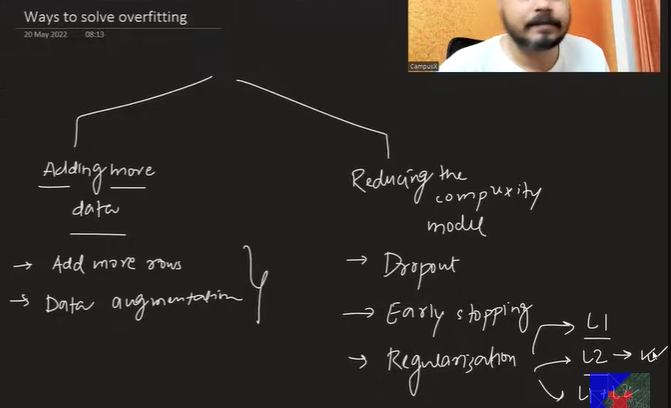

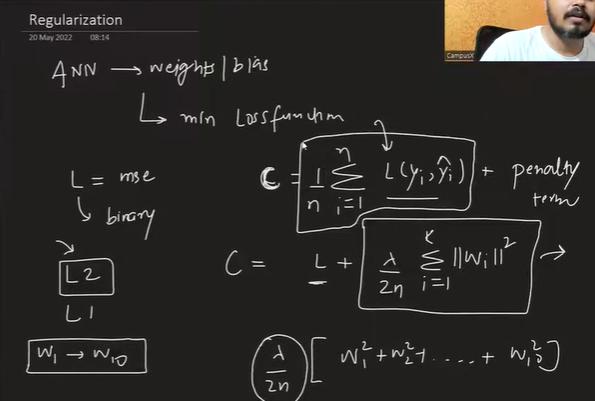

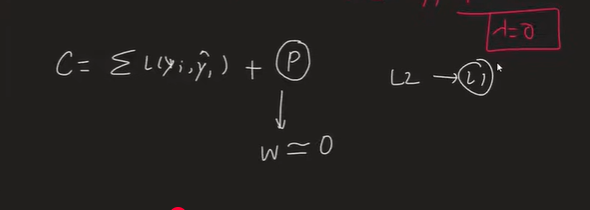

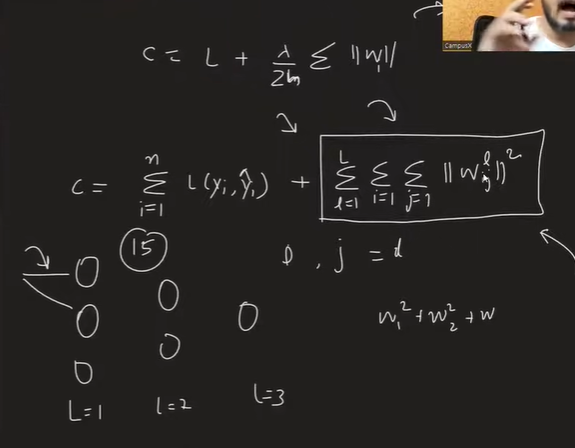

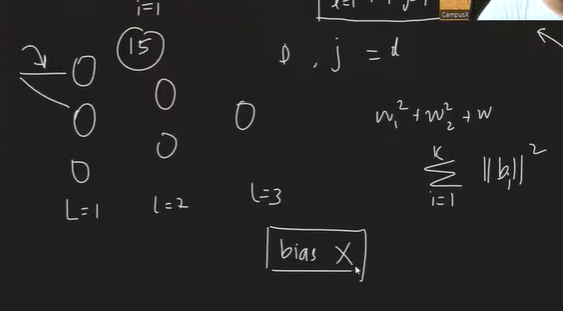

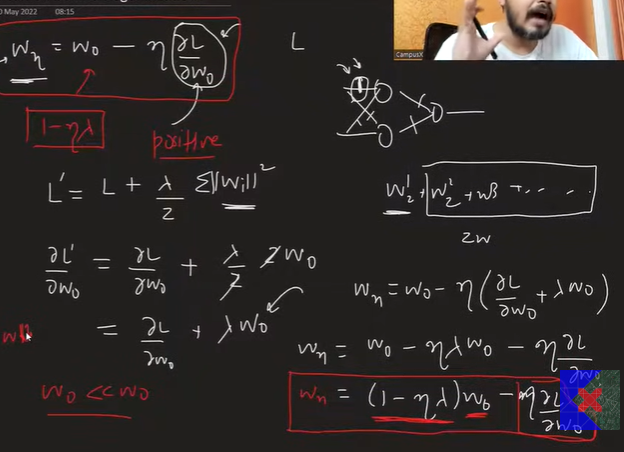

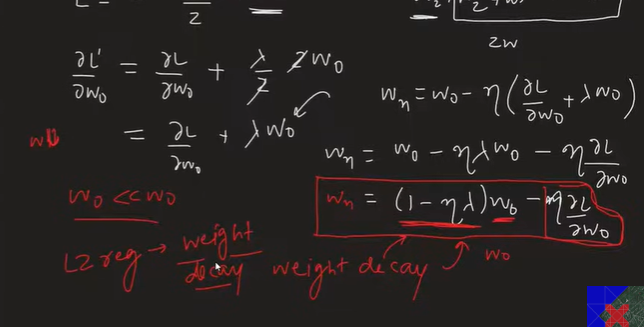

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

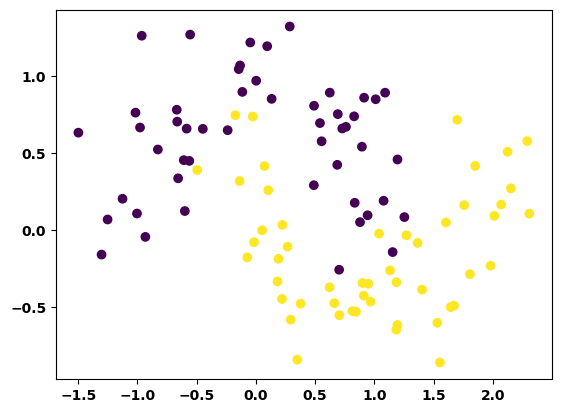

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

c:\Users\Home\anaconda3\envs\eda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

In [ ]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

In [ ]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [ ]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

In [ ]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

In [ ]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [ ]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

In [ ]:
sns.boxplot(model1_weight_layer1)

In [ ]:
sns.boxplot(model2_weight_layer1)

In [ ]:
model1_weight_layer1.min()

In [ ]:
model2_weight_layer1.min()

In [ ]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [ ]:
model1.get_weights()[0].reshape(256)